# Nattharat Wangjaidee 65010321

## หัวข้อ: Time Series Forecasting เปรียบเทียบ Statistics vs ML vs DL

**Dataset ที่เลือก (Kaggle):** Air Passengers
- Kaggle: https://www.kaggle.com/datasets/rakannimer/air-passengers
- ไฟล์: `AirPassengers.csv`
- ช่วงเวลา: 1949-01 ถึง 1960-12 (รวม 144 เดือน มากกว่า 6 เดือน)
- ความสนใจ: พยากรณ์จำนวนผู้โดยสารเครื่องบินรายเดือน

**โมเดลที่เปรียบเทียบ**
1. Statistics: SARIMA
2. ML (Ensemble): Random Forest Regressor (ใช้ lag features)
3. DL: LSTM (หรือ MLP fallback หากไม่มี TensorFlow)

**ตัวชี้วัดประสิทธิภาพ**
- MAE
- RMSE
- MAPE

In [10]:
# ถ้า package ใดยังไม่มี ให้ติดตั้งก่อน (รันครั้งเดียว)
%pip install numpy pandas matplotlib scikit-learn statsmodels kagglehub tensorflow

  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.0/351.2 MB 7.4 MB/s eta 0:00:48
   ---------------------------------------- 2.9/351.2 MB 8.5 MB/s eta 0:00:42
    --------------------------------------- 5.0/351.2 MB 9.2 MB/s eta 0:00:38
    --------------------------------------- 6.6/351.2 MB 8.7 MB/s eta 0:00:40
    --------------------------------------- 8.7/351.2 MB 8.8 MB/s eta 0:00:39
   - -------------------------------------- 10.7/351.2 MB 9.0 MB/s eta 0:00:38
   - -------------------------------------- 12.8/351.2 MB 9.1 MB/s eta 0:00:38
   - -------------------------------------- 15.7/351.2 MB 9.7 MB/s eta 0:00:35
   -- ------------------------------------- 18.6/351.2 MB 10.2 MB/s eta 0:00:33
   -- ------------------------------------- 21.2/351.2 MB 10.4 MB/s eta 0:00:32
   -- ------------------------------------- 25.2/351.2 MB 11.2 MB/s

In [11]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.statespace.sarimax import SARIMAX

# พยายาม import TensorFlow สำหรับ LSTM
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense
    TF_AVAILABLE = True
    print('TensorFlow version:', tf.__version__)
except Exception as e:
    TF_AVAILABLE = False
    print('TensorFlow not available, will use MLP fallback:', e)

# พยายาม import kagglehub เพื่อดึง dataset จาก Kaggle
try:
    import kagglehub
    KAGGLEHUB_AVAILABLE = True
except Exception as e:
    KAGGLEHUB_AVAILABLE = False
    print('kagglehub not available:', e)

TensorFlow version: 2.21.0


Kaggle dataset: rakannimer/air-passengers
CSV path      : C:\Users\SatangLaptop\.cache\kagglehub\datasets\rakannimer\air-passengers\versions\1\AirPassengers.csv
Start: 1949-01-01 00:00:00
End  : 1960-12-01 00:00:00
Months: 144


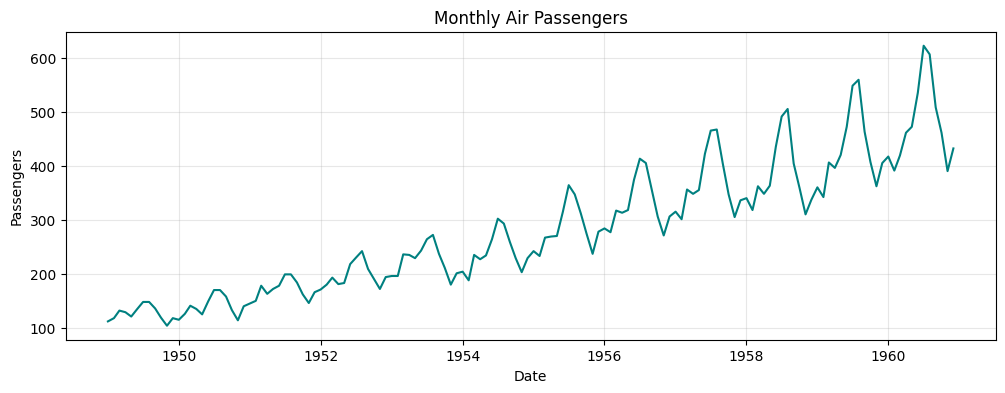

In [12]:
# โหลดชุดข้อมูลจาก Kaggle: Air Passengers
dataset_slug = 'rakannimer/air-passengers'
csv_name = 'AirPassengers.csv'

if KAGGLEHUB_AVAILABLE:
    dataset_path = Path(kagglehub.dataset_download(dataset_slug))
    csv_path = dataset_path / csv_name
elif Path(csv_name).exists():
    csv_path = Path(csv_name)
else:
    raise FileNotFoundError(
        "ไม่พบ AirPassengers.csv และยังไม่ได้ติดตั้ง kagglehub. "
        "ให้รันเซลล์ติดตั้ง package หรือวางไฟล์ AirPassengers.csv ไว้ในโฟลเดอร์โปรเจกต์"
    )

df = pd.read_csv(csv_path)

date_col = next((c for c in df.columns if 'month' in c.lower() or 'date' in c.lower()), df.columns[0])
target_col = next((c for c in df.columns if 'pass' in c.lower()), df.columns[-1])

air_monthly = (
    df[[date_col, target_col]]
    .rename(columns={date_col: 'date', target_col: 'y'})
    .assign(date=lambda x: pd.to_datetime(x['date']))
    .sort_values('date')
    .set_index('date')['y']
    .asfreq('MS')
    .interpolate()
)

# คงชื่อตัวแปรเดิมไว้เพื่อให้โค้ดช่วงถัดไปทำงานต่อได้
co2_monthly = air_monthly

print('Kaggle dataset:', dataset_slug)
print('CSV path      :', csv_path)
print('Start:', co2_monthly.index.min())
print('End  :', co2_monthly.index.max())
print('Months:', len(co2_monthly))

plt.figure(figsize=(12,4))
plt.plot(co2_monthly.index, co2_monthly.values, color='teal')
plt.title('Monthly Air Passengers')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.grid(alpha=0.3)
plt.show()

In [13]:
# แบ่งข้อมูล train/test แบบ time-based
HORIZON = 24  # ทำนาย 24 เดือนสุดท้าย
train = co2_monthly.iloc[:-HORIZON]
test = co2_monthly.iloc[-HORIZON:]

print('Train size:', len(train))
print('Test size :', len(test))

def evaluate_forecast(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape}

def make_lag_df(series, n_lags=12):
    df = pd.DataFrame({'y': series})
    for lag in range(1, n_lags + 1):
        df[f'lag_{lag}'] = df['y'].shift(lag)
    return df.dropna()

Train size: 120
Test size : 24


In [14]:
# 1) Statistics: SARIMA
sarima = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima.fit(disp=False)
sarima_forecast = sarima_fit.forecast(steps=HORIZON)

sarima_result = evaluate_forecast(test.values, sarima_forecast.values, 'SARIMA')
sarima_result

{'Model': 'SARIMA',
 'MAE': 69.89578909065015,
 'RMSE': np.float64(75.62540189425225),
 'MAPE(%)': np.float64(15.22001297488621)}

In [15]:
# 2) ML (Ensemble): Random Forest + recursive forecasting
N_LAGS = 12
lag_train_df = make_lag_df(train, n_lags=N_LAGS)

X_train = lag_train_df.drop(columns='y').values
y_train = lag_train_df['y'].values

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    random_state=42
)
rf.fit(X_train, y_train)

history = train.values.tolist()
rf_preds = []
for _ in range(HORIZON):
    x_input = np.array(history[-N_LAGS:][::-1])[::-1]
    pred = rf.predict(x_input.reshape(1, -1))[0]
    rf_preds.append(pred)
    history.append(pred)

rf_forecast = pd.Series(rf_preds, index=test.index)
rf_result = evaluate_forecast(test.values, rf_forecast.values, 'Random Forest')
rf_result

{'Model': 'Random Forest',
 'MAE': 56.86983333333334,
 'RMSE': np.float64(69.27270788942305),
 'MAPE(%)': np.float64(12.211396329298331)}

In [16]:
# 3) DL: LSTM (RNN) หรือ fallback เป็น MLP
lstm_result = None
lstm_forecast = None

if TF_AVAILABLE:
    WINDOW = 12
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))

    X_lstm, y_lstm = [], []
    for i in range(WINDOW, len(train_scaled)):
        X_lstm.append(train_scaled[i-WINDOW:i, 0])
        y_lstm.append(train_scaled[i, 0])
    X_lstm = np.array(X_lstm).reshape(-1, WINDOW, 1)
    y_lstm = np.array(y_lstm)

    tf.random.set_seed(42)
    model = Sequential([
        LSTM(64, activation='tanh', input_shape=(WINDOW, 1)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_lstm, y_lstm, epochs=50, batch_size=16, verbose=0)

    history_scaled = train_scaled.flatten().tolist()
    preds_scaled = []
    for _ in range(HORIZON):
        x_input = np.array(history_scaled[-WINDOW:]).reshape(1, WINDOW, 1)
        pred_scaled = model.predict(x_input, verbose=0)[0, 0]
        preds_scaled.append(pred_scaled)
        history_scaled.append(pred_scaled)

    preds = scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()
    lstm_forecast = pd.Series(preds, index=test.index)
    lstm_result = evaluate_forecast(test.values, lstm_forecast.values, 'LSTM')
    lstm_result
else:
    # fallback: ใช้ MLPRegressor เป็นโครงข่ายประสาทเทียมเชิงลึกแบบพื้นฐาน
    lag_train_df_dl = make_lag_df(train, n_lags=12)
    X_dl = lag_train_df_dl.drop(columns='y').values
    y_dl = lag_train_df_dl['y'].values

    scaler_x = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_dl_scaled = scaler_x.fit_transform(X_dl)
    y_dl_scaled = scaler_y.fit_transform(y_dl.reshape(-1, 1)).ravel()

    mlp = MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        max_iter=1500,
        random_state=42
)
    mlp.fit(X_dl_scaled, y_dl_scaled)

    history = train.values.tolist()
    dl_preds = []
    for _ in range(HORIZON):
        x_input = np.array(history[-12:]).reshape(1, -1)
        x_input_scaled = scaler_x.transform(x_input)
        pred_scaled = mlp.predict(x_input_scaled)[0]
        pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
        dl_preds.append(pred)
        history.append(pred)

    lstm_forecast = pd.Series(dl_preds, index=test.index)
    lstm_result = evaluate_forecast(test.values, lstm_forecast.values, 'MLP (DL fallback)')
    lstm_result

In [17]:
# รวมผลลัพธ์เชิงตัวเลข
results = [sarima_result, rf_result]
if lstm_result is not None:
    results.append(lstm_result)

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df

,Model,MAE,RMSE,MAPE(%)
0,Random Forest,56.869833,69.272708,12.211396
1,LSTM,51.840687,75.362344,10.147326
2,SARIMA,69.895789,75.625402,15.220013


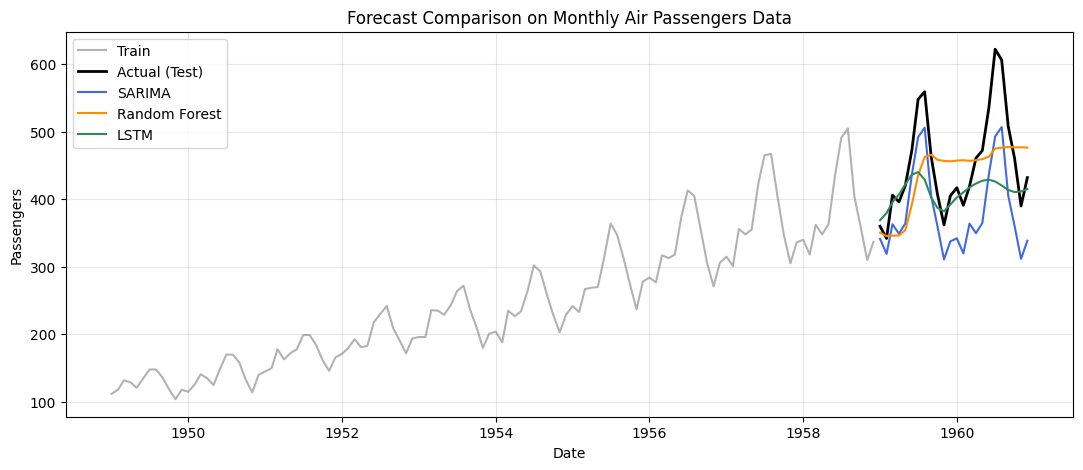

In [18]:
# เปรียบเทียบเส้นจริง vs ค่าพยากรณ์
plt.figure(figsize=(13,5))
plt.plot(train.index, train.values, label='Train', color='gray', alpha=0.6)
plt.plot(test.index, test.values, label='Actual (Test)', color='black', linewidth=2)
plt.plot(test.index, sarima_forecast.values, label='SARIMA', color='royalblue')
plt.plot(test.index, rf_forecast.values, label='Random Forest', color='darkorange')

if lstm_forecast is not None:
    dl_label = lstm_result['Model'] if lstm_result is not None else 'DL Model'
    plt.plot(test.index, lstm_forecast.values, label=dl_label, color='seagreen')

plt.title('Forecast Comparison on Monthly Air Passengers Data')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## สรุปผล
- ใช้ข้อมูลจาก Kaggle: Air Passengers (1949-1960) ซึ่งมีช่วงเวลายาวกว่า 6 เดือน
- SARIMA มักเหมาะกับข้อมูลที่มีแนวโน้มและฤดูกาลชัดเจน
- Random Forest จับความสัมพันธ์ไม่เชิงเส้นจาก lag features ได้ดี
- โมเดล DL (LSTM หรือ MLP fallback) สามารถเรียนรู้รูปแบบลำดับเวลา แต่ใช้ทรัพยากรมากกว่า
